# Despliegue de Modelos: Gradio y HuggingFace Spaces

### De un modelo entrenado a una demo que cualquiera puede probar

En las sesiones anteriores entrenamos y evaluamos modelos. El ultimo paso de un proyecto de Machine Learning es dejarlo disponible para que otras personas lo puedan probar, sin que necesiten saber Python.

`Gradio` permite armar una interfaz web simple para un modelo en muy pocas lineas de codigo. Combinado con `HuggingFace Spaces` (un servicio gratuito para alojar este tipo de demos), podes pasar de "tengo un modelo entrenado" a "tengo un link que le puedo mandar a cualquiera" en minutos.

Vamos a construir un clasificador de osos (grizzly, negro, de peluche) usando `fastai`, y despues lo vamos a envolver en una app de Gradio.

_Nota: este notebook esta basado en un tutorial original de Gradio + HuggingFace Spaces (Tanishq Mathew Abraham, actualizado por Ahmad Hassan)._

## 1. Instalando lo que necesitamos

Ademas de `fastai` (preinstalado en Colab), necesitamos:

- `ddgs`: para buscar imagenes en internet y armar nuestro propio dataset de osos (esta es la libreria que reemplazo a `duckduckgo_search`, que quedo obsoleta).
- `gradio`: para construir la interfaz web de la demo.

In [1]:
!pip install -q -U ddgs
!pip install -q gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 20.1 MB/s eta 0:00:00


In [2]:
import time
from pathlib import Path

from fastcore.all import *
from fastai.vision.all import *
from fastdownload import download_url
from ddgs import DDGS
from ddgs.exceptions import DDGSException

## 2. Armando nuestro propio dataset: fotos de osos

No existe un dataset de "fotos de osos" ya armado y listo para usar, asi que vamos a construir el nuestro buscando imagenes en internet.

### Paso 1: buscar URLs de imagenes

Usamos `ddgs` para buscar imagenes segun una palabra clave. A diferencia de la libreria anterior, `ddgs` reparte la busqueda entre varios motores (DuckDuckGo, Bing, y otros) y solo falla si todos fallan al mismo tiempo -- esto ya la hace bastante mas resistente a que un solo motor nos bloquee. Igual, agregamos una funcion con reintentos y espera creciente entre intentos (`buscar_urls_imagenes`), por si la busqueda falla igual.

In [8]:
def buscar_urls_imagenes(consulta, cantidad=100, intentos=5, espera_inicial=10):
    for intento in range(intentos):
        try:
            resultados = DDGS().images(consulta, max_results=cantidad)  # Busca imagenes relacionadas a la consulta
            return L(resultados).itemgot("image")  # Nos quedamos solo con la URL de cada resultado
        except DDGSException as error:
            espera = espera_inicial * (intento + 1)  # cada intento fallido espera un poco mas que el anterior
            print(f"  la busqueda fallo ({error}); reintentando en {espera}s...")
            time.sleep(espera)
    raise RuntimeError(f"No se pudo completar la busqueda para '{consulta}' despues de {intentos} intentos")


# Probemos con una busqueda chica
urls_de_prueba = buscar_urls_imagenes("grizzly bear", cantidad=5)
urls_de_prueba

['https://cdn.britannica.com/19/186719-050-887A6F2C/Grizzly-bear-Rocky-Mountains-Wyoming.jpg', 'https://wallpapers.com/images/hd/grizzly-bear-pictures-2560-x-2048-o9hsfvsc9zfdzdu9.jpg', 'https://cdn.britannica.com/41/156441-050-A4424AEC/Grizzly-bear-Jasper-National-Park-Canada-Alberta.jpg', 'https://jooinn.com/images/grizzly-bears-3.jpg', 'https://wallup.net/wp-content/uploads/2016/01/30094-bears-nature-animals-Grizzly_bear-Grizzly_Bears.jpg']

### Paso 2: descargar las imagenes, con pausas entre cada una

El metodo `download_images` de fastai descarga las imagenes en paralelo (con varios workers a la vez, sin ninguna pausa entre pedidos). El problema es que muchos servidores bloquean o cortan la conexion cuando reciben demasiados pedidos seguidos desde el mismo lugar en muy poco tiempo -- exactamente lo que pasa al descargar 100+ imagenes en paralelo. El resultado tipico es que terminas con muchas imagenes corruptas o directamente sin descargar.

Para evitar esto, en vez de `download_images` vamos a descargar **una imagen a la vez**, con una pequeña pausa (`time.sleep`) entre cada descarga. Es mas lento, pero mucho mas confiable.

In [4]:
def descargar_imagenes_con_pausa(carpeta, urls, pausa=1.0, maximo=100):
    carpeta.mkdir(parents=True, exist_ok=True)
    descargadas = 0

    for i, url in enumerate(urls[:maximo]):
        try:
            download_url(url, carpeta / f"{i:04d}.jpg", show_progress=False)
            descargadas += 1
        except Exception as error:
            print(f"  no se pudo descargar la imagen {i}: {error}")
        time.sleep(pausa)  # la pausa entre cada descarga es la clave para no ser bloqueados

    return descargadas

### Paso 3: descargar las tres categorias de osos

Guardamos cada categoria en su propia subcarpeta (`osos/grizzly`, `osos/black`, `osos/teddy`), que es la estructura que `fastai` espera para inferir las etiquetas automaticamente a partir del nombre de la carpeta.

Con `pausa=1.0` y 100 imagenes por categoria, esto va a tardar unos minutos (100 imagenes x 1 segundo = ~1.5-2 minutos por categoria, mas la pausa extra entre categorias). Es el precio de que la descarga sea confiable.

In [5]:
tipos_de_oso = ("grizzly", "black", "teddy")
ruta = Path("osos")

if not ruta.exists():
    ruta.mkdir()
    for tipo in tipos_de_oso:
        destino = ruta / tipo
        destino.mkdir(exist_ok=True)

        print(f"Buscando imagenes de: {tipo} bear")
        urls = buscar_urls_imagenes(f"{tipo} bear", cantidad=100)

        cantidad_ok = descargar_imagenes_con_pausa(destino, urls, pausa=1.0)
        print(f"  {cantidad_ok} imagenes descargadas para '{tipo}'")

        time.sleep(5)  # pausa extra entre categorias, para darle un respiro al servicio de busqueda

Buscando imagenes de: grizzly bear
  no se pudo descargar la imagen 10: HTTP Error 403: Forbidden
====Error Body====
<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><meta http-equiv="content-security-policy" content="default-src &#39;none&#39;; script-src &#39;nonce-fLIw0IP8AA169xPy9h4tBN&#39; &#39;unsafe-eval&#39; https://challenges.cloudflare.com; script-src-attr &#39;none&#39;; style-src &#39;unsafe-inline&#39;; img-src &#39;self&#39; https://challenges.cloudflare.com; connect-src &#39;self&#39; https://challenges.cloudflare.com; frame-src &#39;self&#39; https://challenges.cloudflare.com blob:; child-src &#39;self&#39; https://challenges.cloudflare.com blob:; worker-src blob:; form-action http: https:; base-uri &#39;self&#39;"><st

### Paso 4: verificar las imagenes

Aunque ya descargamos con cuidado, vale la pena hacer una segunda pasada de verificacion: a veces un archivo se guarda corrupto o incompleto. `fastai` trae una funcion lista para esto: `verify_images`.

In [6]:
archivos = get_image_files(ruta)
fallidas = verify_images(archivos)
fallidas.map(Path.unlink)  # borra los archivos invalidos

print(f"Total de imagenes: {len(archivos)}")
print(f"Imagenes invalidas eliminadas: {len(fallidas)}")

Total de imagenes: 101
Imagenes invalidas eliminadas: 1


## 3. Preparando los datos con fastai

Con las imagenes organizadas en carpetas por categoria, un `DataBlock` de fastai se encarga de armar los sets de entrenamiento y validacion, incluyendo redimensionar todas las imagenes al mismo tamaño.

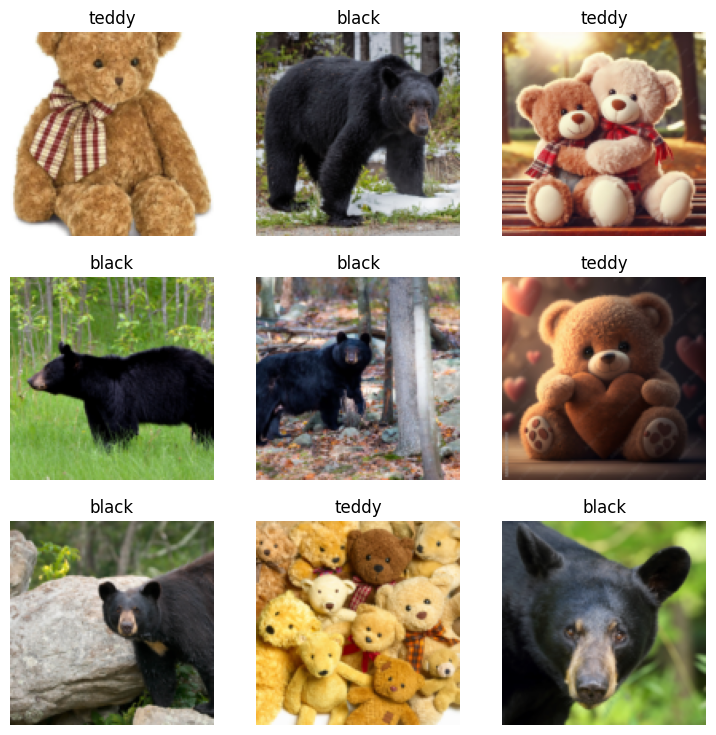

In [9]:
osos = DataBlock(
    blocks=(ImageBlock, CategoryBlock), # Definimos que trabajaremos con imágenes y sus categorías
    get_items=get_image_files, # Buscamos todas las imágenes dentro de la carpeta
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # Separamos aleatoriamente el 20% de las imágenes para el validation set
    get_y=parent_label,  # Usamos el nombre de la carpeta que contiene cada imagen como etiqueta
    item_tfms=Resize(128), # Redimensionamos todas las imágenes a 128x128 píxeles
)

dls = osos.dataloaders(ruta) # Creamos los DataLoaders a partir de la ruta del dataset
dls.show_batch(max_n=9) # Mostramos 9 imágenes del dataset junto con sus etiquetas

## 4. Entrenando el modelo

En vez de armar una CNN desde cero, vamos a usar **transfer learning**: partimos de `resnet18`, una red ya entrenada sobre millones de imagenes (ImageNet), y solo la afinamos (`fine_tune`) con nuestras fotos de osos. Esto funciona muy bien incluso con pocas imagenes por clase, como es nuestro caso.

In [10]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.352364,2.672402,0.600000,00:15


epoch,train_loss,valid_loss,error_rate,time
0,1.943079,1.912349,0.500000,00:25
1,1.791240,0.653026,0.250000,00:20
2,1.329077,0.237124,0.150000,00:19
3,1.054998,0.138511,0.100000,00:18


## 5. Guardando el modelo

`learn.export()` guarda el modelo completo (arquitectura, pesos, y las transformaciones necesarias para preprocesar nuevas imagenes) en un unico archivo `export.pkl`. Este es el archivo que se sube al servidor donde va a vivir la app.

In [11]:
learn.path = Path(".")
learn.export()
print("Modelo guardado en export.pkl")

Modelo guardado en export.pkl


## 6. Usando Gradio

### Paso 1: cargar el modelo

En una app real, este seria un script aparte que arranca de cero: carga el modelo ya entrenado desde el archivo, sin necesidad de volver a entrenar nada.

In [12]:
learn = load_learner("export.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


### Paso 2: la funcion de prediccion

Gradio necesita una funcion que reciba una imagen y devuelva un resultado. `learn.predict()` ya hace todo el trabajo pesado (preprocesar la imagen, correr el modelo); nosotros solo tenemos que acomodar el resultado en el formato que espera Gradio: un diccionario `{categoria: probabilidad}`.

In [14]:
etiquetas = learn.dls.vocab


def predecir(imagen):
    imagen = PILImage.create(imagen)
    _, _, probabilidades = learn.predict(imagen)
    return {etiquetas[i]: float(probabilidades[i]) for i in range(len(etiquetas))}

### Paso 3: crear y lanzar la interfaz

In [15]:
import gradio as gr

demo = gr.Interface(
    fn=predecir,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0234e9e8bcab02edaf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Eso es todo. `share=True` genera un link publico temporal que le podes mandar a cualquiera para que pruebe tu modelo desde el navegador, sin instalar nada.

## 7. Personalizando la app (opcional)

Gradio permite agregar titulo, descripcion, y otros elementos, pasandolos como argumentos extra al crear el `Interface`.

In [16]:
titulo = "Clasificador de Osos"
descripcion = "Sube una foto de un oso y el modelo va a decir si es grizzly, negro o de peluche."
articulo = "<p style='text-align: center'>Notebook adaptado para el curso PY4 - Deep Learning y NLP</p>"

demo = gr.Interface(
    fn=predecir,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title=titulo,
    description=descripcion,
    article=articulo,
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9ae4dbacc033d71b7f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Siguiente paso: HuggingFace Spaces

El link que genera `share=True` es temporal (se cae cuando cerras el notebook). Para tener una demo permanente y gratuita, el siguiente paso es publicarla en `HuggingFace Spaces`:

1. Crear un Space nuevo en huggingface.co, eligiendo Gradio como tipo de app.
2. Subir tres cosas: el archivo del modelo (`export.pkl`), un `app.py` con el mismo codigo de `predecir()` y `gr.Interface()` que ya escribimos, y un `requirements.txt` con las librerias necesarias (`fastai`, `gradio`).
3. HuggingFace levanta la app automaticamente, con una URL permanente.

No lo vamos a hacer dentro de este notebook (ese paso se hace fuera de Jupyter, en la web de HuggingFace), pero con `export.pkl` y la funcion `predecir()`, ya tenes todo lo necesario.

## Resumen

- Armamos nuestro propio dataset buscando y descargando imagenes de internet, **con pausas entre cada descarga** para evitar que los servidores nos bloqueen.
- Usamos `fastai` y transfer learning (`resnet18` + `fine_tune`) para entrenar un clasificador con pocas imagenes por clase.
- Guardamos el modelo (`learn.export()`) y lo volvimos a cargar (`load_learner()`), como se haria en produccion.
- Construimos una interfaz con Gradio para que cualquier persona pueda probar el modelo desde el navegador.

La parte de "descargar datos de internet con cuidado" no es exclusiva de este ejercicio: cualquier vez que armes un dataset scrapeando la web, agregar pausas entre pedidos es una practica basica para no terminar bloqueado.